# 01 EDA: Data Diagnostics for Startup Outcome Prediction

This notebook separates the exploratory and diagnostic checks from preprocessing. It is designed to support the thesis methodology/results write-up around the following sections:

- **4.2.1 Missing Data**
- **4.2.2 Temporal Coverage and Time-Order Checks**
- **4.2.3 Funding Variable Distributions**
- **4.2.4 Geographic and Market Distributions**
- **4.2.5 Data Quality and Leakage-Risk Diagnostics**

Important workflow decision:
1. The raw **status distribution** is inspected first to document the original outcome/status composition.
2. The EDA is then conducted on the binary classification sample only, retaining firms with `status == acquired` or `status == closed`.

This keeps the descriptive diagnostics aligned with the final modeling population while still documenting why operating and other non-terminal statuses are excluded from modeling.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path('/Users/bettykim/Desktop/Thesis/Code')

DATA_DIR = PROJECT_DIR / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
OUTPUT_DIR = PROJECT_DIR / 'outputs'

EDA_TABLE_DIR = OUTPUT_DIR / 'tables' / 'eda'
EDA_FIGURE_DIR = OUTPUT_DIR / 'figures' / 'eda'

EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV_PATH = RAW_DATA_DIR / 'investments_VC.csv'

MIN_FIRST_FUNDING_YEAR = 1990

post_outcome_or_leakage_risk_cols = [
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market'
]

print('Project directory:', PROJECT_DIR)
print('Raw CSV path:', RAW_CSV_PATH)
print('Raw CSV exists:', RAW_CSV_PATH.exists())
print('EDA table directory:', EDA_TABLE_DIR)
print('EDA figure directory:', EDA_FIGURE_DIR)

Project directory: /Users/bettykim/Desktop/Thesis/Code
Raw CSV path: /Users/bettykim/Desktop/Thesis/Code/data/raw/investments_VC.csv
Raw CSV exists: True
EDA table directory: /Users/bettykim/Desktop/Thesis/Code/outputs/tables/eda
EDA figure directory: /Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda


## 1. Load raw data

The raw file is loaded before any modeling-specific filtering. Column names are normalized only for easier reference in the EDA code.

In [10]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df

# Use latin1 because the Crunchbase/Kaggle CSV often contains non-UTF-8 characters.
df_raw = pd.read_csv(RAW_CSV_PATH, encoding='latin1')
df_raw = normalize_columns(df_raw)

print('Raw shape:', df_raw.shape)
display(df_raw.head())

Raw shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Raw status distribution before binary-sample filtering

This table documents the original status composition of the dataset. It should be reported before filtering because it justifies why the modeling sample is restricted to terminal outcomes. In this thesis, `acquired` is coded as the positive outcome and `closed` as the negative outcome, while `operating` and other non-terminal or missing statuses are excluded from the binary classification task.

,status,count,percentage
0,operating,41829,77.041662
1,missing,6170,11.364055
2,acquired,3692,6.800015
3,closed,2603,4.794268


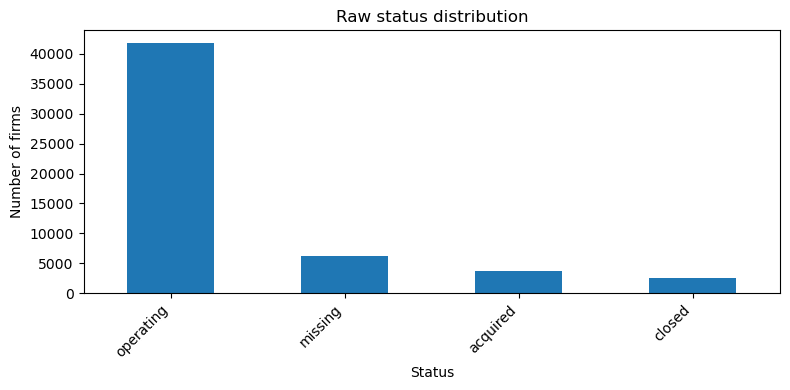

In [11]:
status_counts = (
    df_raw['status']
    .fillna('missing')
    .value_counts(dropna=False)
    .rename_axis('status')
    .reset_index(name='count')
)
status_counts['percentage'] = status_counts['count'] / len(df_raw) * 100
status_counts.to_csv(EDA_TABLE_DIR / 'raw_status_distribution.csv', index=False)

display(status_counts)

ax = status_counts.plot(kind='bar', x='status', y='count', legend=False, figsize=(8, 4))
ax.set_title('Raw status distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Number of firms')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(EDA_FIGURE_DIR / 'raw_status_distribution.png', dpi=300)
plt.show()

## 3. Create the binary EDA sample: acquired vs closed only

All subsequent EDA is conducted on the same outcome population that will be used for modeling. This avoids describing patterns from operating firms that are not part of the final binary classification task.

In [12]:
terminal_statuses = ['acquired', 'closed']
df_eda = df_raw[df_raw['status'].isin(terminal_statuses)].copy()
df_eda['outcome'] = (df_eda['status'] == 'acquired').astype(int)

binary_status_counts = (
    df_eda['status']
    .value_counts()
    .rename_axis('status')
    .reset_index(name='count')
)
binary_status_counts['percentage'] = binary_status_counts['count'] / len(df_eda) * 100
binary_status_counts.to_csv(EDA_TABLE_DIR / 'binary_sample_status_distribution.csv', index=False)

print('Binary EDA sample shape:', df_eda.shape)
display(binary_status_counts)

Binary EDA sample shape: (6295, 40)


,status,count,percentage
0,acquired,3692,58.649722
1,closed,2603,41.350278


# 4.2.1 Missing Data

This section checks missingness after restricting the data to acquired and closed firms. The output supports a thesis discussion of which variables have substantial missingness and which variables may require imputation, exclusion, or missingness indicators.

Suggested thesis wording after running this notebook:

> Missingness was assessed after restricting the sample to firms with terminal outcomes (`acquired` and `closed`). This ensures that missing-data patterns are evaluated for the same population used in the predictive modeling task. Variables with high missingness were inspected separately from variables with moderate missingness, and date-related missingness was examined because temporal variables are used both for feature construction and temporal evaluation design.

In [15]:
missing_table = (
    df_eda.isna().mean()
    .sort_values(ascending=False)
    .rename('missing_ratio')
    .reset_index()
    .rename(columns={'index': 'variable'})
)

missing_table['missing_count'] = df_eda[missing_table['variable']].isna().sum().values
missing_table['missing_pct'] = missing_table['missing_ratio'] * 100

missing_table = missing_table[
    ['variable', 'missing_count', 'missing_ratio', 'missing_pct']
]

missing_table.to_csv(
    EDA_TABLE_DIR / 'missing_data_binary_sample.csv',
    index=False
)

display_table = missing_table.copy()
display_table['missing_pct'] = display_table['missing_pct'].map(lambda x: f'{x:.2f}')

display(display_table)

,variable,missing_count,missing_ratio,missing_pct
0,state_code,1878,0.298332,29.83
1,founded_month,1328,0.210961,21.10
2,founded_year,1328,0.210961,21.10
3,founded_quarter,1328,0.210961,21.10
4,founded_at,1323,0.210167,21.02
5,city,691,0.109770,10.98
6,country_code,628,0.099762,9.98
7,region,628,0.099762,9.98
8,homepage_url,285,0.045274,4.53
9,market,231,0.036696,3.67


# 4.2.2 Temporal Coverage and Time-Order Checks

This section examines the temporal range of the binary sample and identifies time-order problems. These checks are important because the thesis uses a blocked temporal evaluation design and relies on funding dates for sample construction and temporal ordering.

The key checks are:
- Whether date columns parse correctly.
- The coverage of `founded_at`, `first_funding_at`, and `last_funding_at`.
- Rows where `founded_at > first_funding_at`.
- Rows where `first_funding_at > last_funding_at`.
- Rows where `first_funding_at` is earlier than the minimum analysis year.

Suggested thesis wording after running this notebook:

> Temporal diagnostics were conducted to verify whether the chronological ordering of founding and funding dates was plausible. Observations with inconsistent time ordering, such as founding dates after first funding dates or first funding dates after last funding dates, were flagged because they conflict with the temporal logic required for the blocked evaluation design.

In [13]:
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at']
date_cols = [c for c in date_cols if c in df_eda.columns]

for col in date_cols:
    df_eda[col] = pd.to_datetime(df_eda[col], errors='coerce')

coverage_rows = []
for col in date_cols:
    s = df_eda[col]
    coverage_rows.append({
        'date_variable': col,
        'non_missing_count': int(s.notna().sum()),
        'missing_count': int(s.isna().sum()),
        'min_date': s.min(),
        'max_date': s.max(),
    })

temporal_coverage = pd.DataFrame(coverage_rows)
temporal_coverage.to_csv(EDA_TABLE_DIR / 'temporal_coverage.csv', index=False)
display(temporal_coverage)

,date_variable,non_missing_count,missing_count,min_date,max_date
0,founded_at,4972,1323,1840-01-01,2014-07-01
1,first_funding_at,6295,0,11-11-14,2014-12-01
2,last_funding_at,6295,0,1960-01-01,2014-12-01


In [14]:
# ============================================================
# 4.2.2 Temporal Coverage and Time-Order Checks
# ============================================================

date_cols = [
    "founded_at",
    "first_funding_at",
    "last_funding_at"
]

for col in date_cols:
    if col in df_eda.columns:
        df_eda[col] = pd.to_datetime(df_eda[col], errors="coerce")

available_date_cols = [col for col in date_cols if col in df_eda.columns]

print("Available date columns:")
print(available_date_cols)

Available date columns:
['founded_at', 'first_funding_at', 'last_funding_at']


In [47]:
# Exclude pre-1960 years only for visualization
temporal_coverage_clean = temporal_coverage[
    temporal_coverage["year"] >= 1960
].copy()

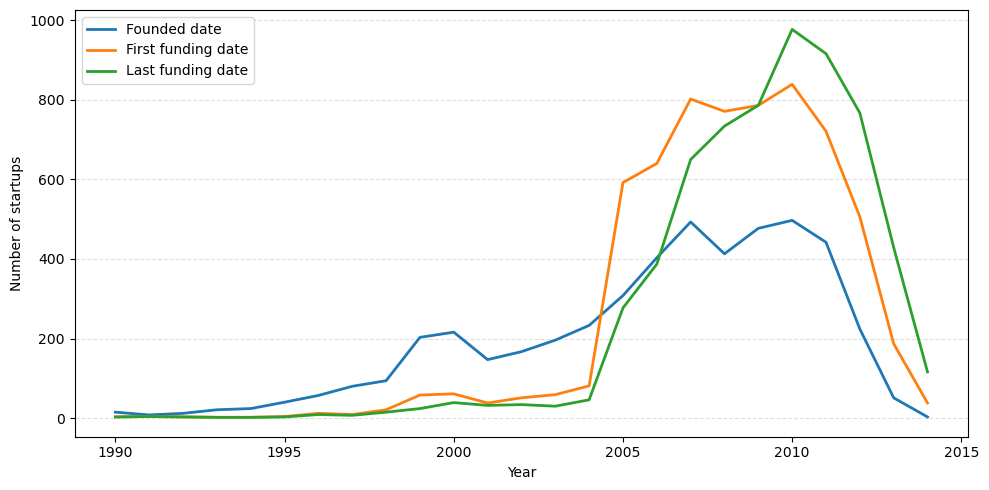

In [23]:
# Yearly temporal coverage of key date variables

temporal_coverage = []

for col in available_date_cols:
    year_counts = (
        df_eda[col]
        .dropna()
        .dt.year
        .value_counts()
        .sort_index()
    )
    
    for year, count in year_counts.items():
        temporal_coverage.append({
            "year": int(year),
            "date_variable": col,
            "count": int(count)
        })

temporal_coverage = pd.DataFrame(temporal_coverage)

# Exclude implausible early years only for visualization
temporal_coverage_clean = temporal_coverage[
    temporal_coverage["year"] >= 1990
].copy()

temporal_coverage_clean["date_variable"] = temporal_coverage_clean["date_variable"].replace({
    "founded_at": "Founded date",
    "first_funding_at": "First funding date",
    "last_funding_at": "Last funding date"
})

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=temporal_coverage_clean,
    x="year",
    y="count",
    hue="date_variable",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Number of startups")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title=None)
plt.tight_layout()

plt.savefig(
    EDA_FIGURE_DIR / "temporal_coverage_date_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
display(
    temporal_coverage[temporal_coverage["year"] < 1900]
    .sort_values("year")
)

,year,date_variable,count
56,11,first_funding_at,1
0,1840,founded_at,2
1,1863,founded_at,2
2,1896,founded_at,1


,first_funding_decade,count,pct_of_binary_sample,remaining_pct_after_cutoff
0,Before 1960,1,0.02,100.00
1,1960-1969,2,0.03,99.98
2,1970-1979,0,0.00,99.95
3,1980-1989,2,0.03,99.95
4,1990-1999,118,1.87,99.92
5,2000-2009,3881,61.65,98.05
6,2010-2019,2291,36.39,36.39


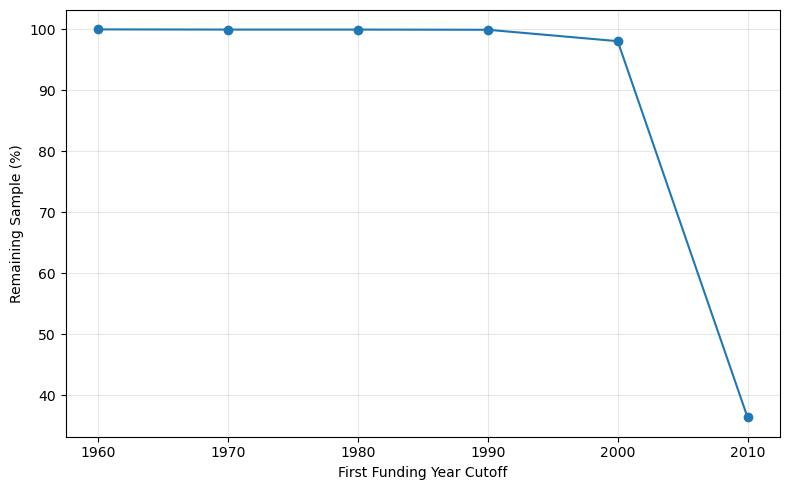

In [28]:
# Temporal coverage summary by decade and cutoff year
# Based on first_funding_at, used for temporal split diagnostics.
# This diagnostic uses a copy of df_eda, so the original df_eda is not modified.

if 'first_funding_at' in df_eda.columns:
    df_first_funding = df_eda.copy()

    df_first_funding['first_funding_year'] = (
        df_first_funding['first_funding_at'].dt.year
    )

    total_n = len(df_first_funding)

    # -----------------------------
    # 1. Decade-level distribution
    # -----------------------------

    decade_bins = [-float('inf'), 1960, 1970, 1980, 1990, 2000, 2010, 2020]
    decade_labels = [
        'Before 1960',
        '1960-1969',
        '1970-1979',
        '1980-1989',
        '1990-1999',
        '2000-2009',
        '2010-2019'
    ]

    df_first_funding['first_funding_decade'] = pd.cut(
        df_first_funding['first_funding_year'],
        bins=decade_bins,
        labels=decade_labels,
        right=False
    )

    first_funding_decade_total_summary = (
        df_first_funding
        .groupby('first_funding_decade', observed=False)
        .size()
        .reset_index(name='count')
    )

    first_funding_decade_total_summary['pct_of_binary_sample'] = (
        first_funding_decade_total_summary['count'] / total_n * 100
    ).map(lambda x: f'{x:.2f}')

    # -----------------------------
    # 2. Cutoff-year summary
    # -----------------------------

    cutoffs = [1960, 1970, 1980, 1990, 2000, 2010]
    cutoff_summary = []

    for cutoff in cutoffs:
        temp = df_first_funding[
            df_first_funding['first_funding_year'] >= cutoff
        ]

        cutoff_summary.append({
            'cutoff_year': cutoff,
            'remaining_n': len(temp),
            'remaining_pct': round(len(temp) / total_n * 100, 2),
            'acquired_n': int((temp['status'] == 'acquired').sum()),
            'closed_n': int((temp['status'] == 'closed').sum()),
            'acquired_pct_within_remaining': round((temp['status'] == 'acquired').mean() * 100, 2) if len(temp) > 0 else 0,
            'closed_pct_within_remaining': round((temp['status'] == 'closed').mean() * 100, 2) if len(temp) > 0 else 0
        })

    first_funding_cutoff_summary_df = pd.DataFrame(cutoff_summary)

    # -----------------------------
    # 3. Combined summary table
    # -----------------------------

    remaining_pct_map = {
        'Before 1960': 100.00,
        '1960-1969': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 1960, 'remaining_pct'
        ].iloc[0],
        '1970-1979': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 1970, 'remaining_pct'
        ].iloc[0],
        '1980-1989': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 1980, 'remaining_pct'
        ].iloc[0],
        '1990-1999': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 1990, 'remaining_pct'
        ].iloc[0],
        '2000-2009': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 2000, 'remaining_pct'
        ].iloc[0],
        '2010-2019': first_funding_cutoff_summary_df.loc[
            first_funding_cutoff_summary_df['cutoff_year'] == 2010, 'remaining_pct'
        ].iloc[0]
    }

    first_funding_decade_total_summary['remaining_pct_after_cutoff'] = (
        first_funding_decade_total_summary['first_funding_decade']
        .astype(str)
        .map(lambda x: f"{remaining_pct_map[x]:.2f}")
    )

    combined_first_funding_summary = first_funding_decade_total_summary[
        [
            'first_funding_decade',
            'count',
            'pct_of_binary_sample',
            'remaining_pct_after_cutoff'
        ]
    ].copy()

    combined_first_funding_summary.to_csv(
        EDA_TABLE_DIR / 'first_funding_decade_combined_summary.csv',
        index=False
    )

    display(combined_first_funding_summary)

    # Optional: keep cutoff summary separately
    first_funding_cutoff_summary_df.to_csv(
        EDA_TABLE_DIR / 'first_funding_cutoff_summary.csv',
        index=False
    )

    # -----------------------------
    # 4. Cutoff-year remaining sample plot
    # -----------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        first_funding_cutoff_summary_df['cutoff_year'],
        first_funding_cutoff_summary_df['remaining_pct'],
        marker='o'
    )

    plt.xlabel('First Funding Year Cutoff')
    plt.ylabel('Remaining Sample (%)')
    plt.xticks(first_funding_cutoff_summary_df['cutoff_year'])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURE_DIR / 'remaining_sample_percentage_by_first_funding_cutoff.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

else:
    print("Column 'first_funding_at' was not found in df_eda.")

Founded-year diagnostic basis:
Total binary analytic sample: 6295
Missing founded_year before imputation: 1328
Missing founded_year after imputation: 0
Minimum founded_year_imputed: 1911.0
Maximum founded_year_imputed: 2014.0

Founded-year exact distribution after imputation:


,founded_year_imputed,count,pct_of_binary_sample
0,1911,1,0.02
1,1934,1,0.02
2,1948,2,0.03
3,1949,1,0.02
4,1959,1,0.02
5,1960,2,0.03
6,1963,1,0.02
7,1967,2,0.03
8,1968,1,0.02
9,1969,3,0.05



Founded-year exact cutoff sensitivity summary after imputation:


,cutoff_year,remaining_n,remaining_pct,removed_n,removed_pct,acquired_n,closed_n,acquired_pct_within_remaining,closed_pct_within_remaining
0,1911,6295,100.00,0,0.00,3692,2603,58.65,41.35
1,1912,6294,99.98,1,0.02,3691,2603,58.64,41.36
2,1913,6294,99.98,1,0.02,3691,2603,58.64,41.36
3,1914,6294,99.98,1,0.02,3691,2603,58.64,41.36
4,1915,6294,99.98,1,0.02,3691,2603,58.64,41.36
...,...,...,...,...,...,...,...,...,...
99,2010,1652,26.24,4643,73.76,754,898,45.64,54.36
100,2011,986,15.66,5309,84.34,468,518,47.46,52.54
101,2012,407,6.47,5888,93.53,197,210,48.40,51.60
102,2013,95,1.51,6200,98.49,55,40,57.89,42.11



Largest drops when increasing the founded-year cutoff:


,cutoff_year,remaining_n,remaining_pct,removed_n,removed_pct,acquired_n,closed_n,acquired_pct_within_remaining,closed_pct_within_remaining,remaining_pct_drop_from_previous_cutoff,remaining_n_drop_from_previous_cutoff
99,2010,1652,26.24,4643,73.76,754,898,45.64,54.36,10.76,677.0
100,2011,986,15.66,5309,84.34,468,518,47.46,52.54,10.58,666.0
97,2008,2926,46.48,3369,53.52,1345,1581,45.97,54.03,10.45,658.0
98,2009,2329,37.00,3966,63.00,1081,1248,46.41,53.59,9.48,597.0
101,2012,407,6.47,5888,93.53,197,210,48.40,51.60,9.19,579.0
96,2007,3584,56.93,2711,43.07,1676,1908,46.76,53.24,8.87,558.0
95,2006,4142,65.80,2153,34.20,2019,2123,48.74,51.26,6.65,419.0
102,2013,95,1.51,6200,98.49,55,40,57.89,42.11,4.96,312.0
94,2005,4561,72.45,1734,27.55,2295,2266,50.32,49.68,3.98,250.0
90,2001,5356,85.08,939,14.92,2894,2462,54.03,45.97,3.64,229.0


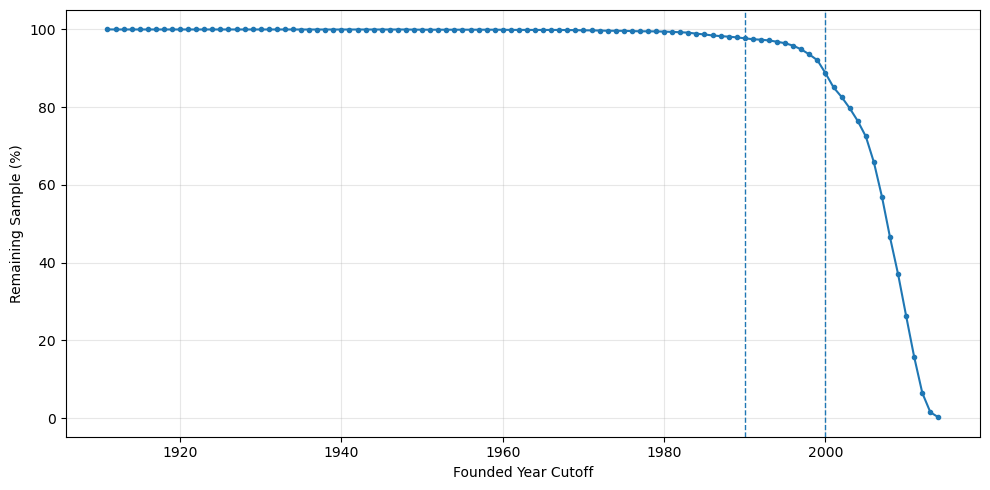

In [25]:
# Founded-year diagnostic by exact year
# Missing founded_year values are imputed using first_funding_at year.
# This matches the preprocessing logic and uses a copy of df_eda, so df_eda is not modified.

if 'founded_year' in df_eda.columns and 'first_funding_at' in df_eda.columns:
    df_founded_cutoff = df_eda.copy()

    df_founded_cutoff['founded_year_numeric'] = pd.to_numeric(
        df_founded_cutoff['founded_year'],
        errors='coerce'
    )

    df_founded_cutoff['first_funding_year'] = (
        df_founded_cutoff['first_funding_at'].dt.year
    )

    df_founded_cutoff['founded_year_imputed'] = (
        df_founded_cutoff['founded_year_numeric']
        .fillna(df_founded_cutoff['first_funding_year'])
    )

    total_n = len(df_founded_cutoff)

    print("Founded-year diagnostic basis:")
    print("Total binary analytic sample:", total_n)
    print("Missing founded_year before imputation:", df_founded_cutoff['founded_year_numeric'].isna().sum())
    print("Missing founded_year after imputation:", df_founded_cutoff['founded_year_imputed'].isna().sum())
    print("Minimum founded_year_imputed:", df_founded_cutoff['founded_year_imputed'].min())
    print("Maximum founded_year_imputed:", df_founded_cutoff['founded_year_imputed'].max())

    # -----------------------------
    # 1. Exact-year distribution
    # -----------------------------

    founded_year_summary = (
        df_founded_cutoff
        .dropna(subset=['founded_year_imputed'])
        .groupby('founded_year_imputed')
        .size()
        .reset_index(name='count')
        .sort_values('founded_year_imputed')
    )

    founded_year_summary['founded_year_imputed'] = (
        founded_year_summary['founded_year_imputed'].astype(int)
    )

    founded_year_summary['pct_of_binary_sample'] = (
        founded_year_summary['count'] / total_n * 100
    ).round(2)

    founded_year_summary.to_csv(
        EDA_TABLE_DIR / 'founded_year_exact_distribution_imputed.csv',
        index=False
    )

    print("\nFounded-year exact distribution after imputation:")
    display(founded_year_summary)

    # -----------------------------
    # 2. Exact-year cutoff sensitivity
    # -----------------------------

    min_year = int(df_founded_cutoff['founded_year_imputed'].min())
    max_year = int(df_founded_cutoff['founded_year_imputed'].max())

    cutoff_summary = []

    for cutoff in range(min_year, max_year + 1):
        temp = df_founded_cutoff[
            df_founded_cutoff['founded_year_imputed'] >= cutoff
        ]

        cutoff_summary.append({
            'cutoff_year': cutoff,
            'remaining_n': len(temp),
            'remaining_pct': round(len(temp) / total_n * 100, 2),
            'removed_n': total_n - len(temp),
            'removed_pct': round((total_n - len(temp)) / total_n * 100, 2),
            'acquired_n': int((temp['status'] == 'acquired').sum()),
            'closed_n': int((temp['status'] == 'closed').sum()),
            'acquired_pct_within_remaining': round((temp['status'] == 'acquired').mean() * 100, 2) if len(temp) > 0 else 0,
            'closed_pct_within_remaining': round((temp['status'] == 'closed').mean() * 100, 2) if len(temp) > 0 else 0
        })

    founded_cutoff_summary_df = pd.DataFrame(cutoff_summary)

    founded_cutoff_summary_df.to_csv(
        EDA_TABLE_DIR / 'founded_year_exact_cutoff_summary_imputed.csv',
        index=False
    )

    print("\nFounded-year exact cutoff sensitivity summary after imputation:")
    display(founded_cutoff_summary_df)

    # -----------------------------
    # 3. Identify large drops
    # -----------------------------

    founded_cutoff_summary_df['remaining_pct_drop_from_previous_cutoff'] = (
        founded_cutoff_summary_df['remaining_pct'].shift(1) -
        founded_cutoff_summary_df['remaining_pct']
    )

    founded_cutoff_summary_df['remaining_n_drop_from_previous_cutoff'] = (
        founded_cutoff_summary_df['remaining_n'].shift(1) -
        founded_cutoff_summary_df['remaining_n']
    )

    largest_drops = (
        founded_cutoff_summary_df
        .dropna(subset=['remaining_pct_drop_from_previous_cutoff'])
        .sort_values('remaining_pct_drop_from_previous_cutoff', ascending=False)
        .head(15)
    )

    largest_drops.to_csv(
        EDA_TABLE_DIR / 'founded_year_largest_cutoff_drops_imputed.csv',
        index=False
    )

    print("\nLargest drops when increasing the founded-year cutoff:")
    display(largest_drops)

    # -----------------------------
    # 4. Plot: remaining sample percentage by exact cutoff year
    # -----------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        founded_cutoff_summary_df['cutoff_year'],
        founded_cutoff_summary_df['remaining_pct'],
        marker='o',
        markersize=3
    )

    plt.axvline(1990, linestyle='--', linewidth=1)
    plt.axvline(2000, linestyle='--', linewidth=1)

    plt.xlabel('Founded Year Cutoff')
    plt.ylabel('Remaining Sample (%)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURE_DIR / 'remaining_sample_percentage_by_exact_founded_year_cutoff_imputed.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

else:
    print("Required columns 'founded_year' and/or 'first_funding_at' were not found in df_eda.")

Founded-year imputation diagnostic:
Total binary analytic sample: 6295
Missing founded_year before imputation: 1328
Missing founded_year after imputation: 0


,founded_decade,count,pct_of_binary_sample,remaining_pct_after_cutoff
0,Before 1960,6,0.10,100.00
1,1960-1969,9,0.14,99.90
2,1970-1979,21,0.33,99.76
3,1980-1989,108,1.72,99.43
4,1990-1999,566,8.99,97.71
5,2000-2009,3933,62.48,88.72
6,2010-2019,1652,26.24,26.24


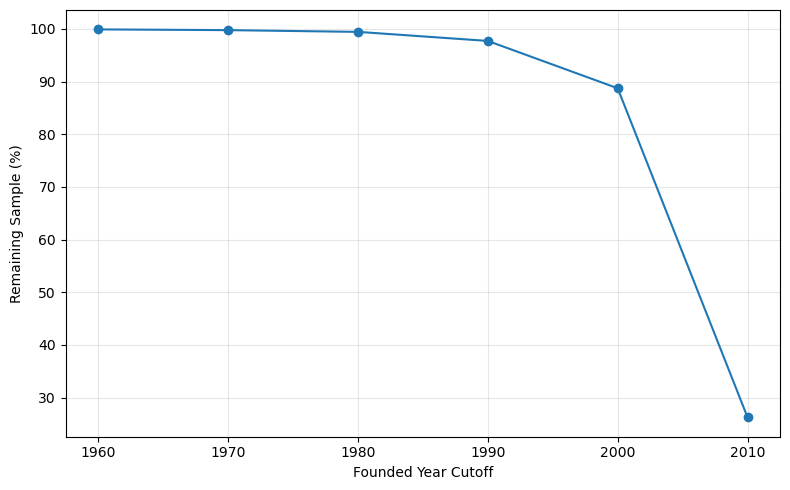

In [29]:
# Temporal coverage summary by decade and cutoff year
# Based on founded_year after imputation.
# Missing founded_year values are imputed using first_funding_at year.
# This diagnostic uses a copy of df_eda, so df_eda is not modified.

if 'founded_year' in df_eda.columns and 'first_funding_at' in df_eda.columns:
    df_founded = df_eda.copy()

    df_founded['founded_year_numeric'] = pd.to_numeric(
        df_founded['founded_year'],
        errors='coerce'
    )

    df_founded['first_funding_year'] = df_founded['first_funding_at'].dt.year

    df_founded['founded_year_imputed'] = (
        df_founded['founded_year_numeric']
        .fillna(df_founded['first_funding_year'])
    )

    total_n = len(df_founded)

    print("Founded-year imputation diagnostic:")
    print("Total binary analytic sample:", total_n)
    print("Missing founded_year before imputation:", df_founded['founded_year_numeric'].isna().sum())
    print("Missing founded_year after imputation:", df_founded['founded_year_imputed'].isna().sum())

    # -----------------------------
    # 1. Decade-level distribution
    # -----------------------------

    decade_bins = [-float('inf'), 1960, 1970, 1980, 1990, 2000, 2010, 2020]
    decade_labels = [
        'Before 1960',
        '1960-1969',
        '1970-1979',
        '1980-1989',
        '1990-1999',
        '2000-2009',
        '2010-2019'
    ]

    df_founded['founded_decade'] = pd.cut(
        df_founded['founded_year_imputed'],
        bins=decade_bins,
        labels=decade_labels,
        right=False
    )

    founded_decade_total_summary = (
        df_founded
        .groupby('founded_decade', observed=False)
        .size()
        .reset_index(name='count')
    )

    founded_decade_total_summary['pct_of_binary_sample'] = (
        founded_decade_total_summary['count'] / total_n * 100
    ).map(lambda x: f'{x:.2f}')

    # -----------------------------
    # 2. Cutoff-year summary
    # -----------------------------

    cutoffs = [1960, 1970, 1980, 1990, 2000, 2010]
    cutoff_summary = []

    for cutoff in cutoffs:
        temp = df_founded[
            df_founded['founded_year_imputed'] >= cutoff
        ]

        cutoff_summary.append({
            'cutoff_year': cutoff,
            'remaining_n': len(temp),
            'remaining_pct': round(len(temp) / total_n * 100, 2)
        })

    founded_cutoff_summary_df = pd.DataFrame(cutoff_summary)

    # -----------------------------
    # 3. Combined summary table
    # -----------------------------

    remaining_pct_map = {
        'Before 1960': 100.00,
        '1960-1969': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 1960, 'remaining_pct'
        ].iloc[0],
        '1970-1979': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 1970, 'remaining_pct'
        ].iloc[0],
        '1980-1989': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 1980, 'remaining_pct'
        ].iloc[0],
        '1990-1999': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 1990, 'remaining_pct'
        ].iloc[0],
        '2000-2009': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 2000, 'remaining_pct'
        ].iloc[0],
        '2010-2019': founded_cutoff_summary_df.loc[
            founded_cutoff_summary_df['cutoff_year'] == 2010, 'remaining_pct'
        ].iloc[0]
    }

    founded_decade_total_summary['remaining_pct_after_cutoff'] = (
        founded_decade_total_summary['founded_decade']
        .astype(str)
        .map(lambda x: f"{remaining_pct_map[x]:.2f}")
    )

    combined_summary = founded_decade_total_summary[
        ['founded_decade', 'count', 'pct_of_binary_sample', 'remaining_pct_after_cutoff']
    ].copy()

    combined_summary.to_csv(
        EDA_TABLE_DIR / 'founded_decade_combined_summary_imputed.csv',
        index=False
    )

    display(combined_summary)

    # Optional: keep raw cutoff summary too
    founded_cutoff_summary_df.to_csv(
        EDA_TABLE_DIR / 'founded_year_cutoff_summary_imputed.csv',
        index=False
    )

    # -----------------------------
    # 4. Cutoff-year remaining sample plot
    # -----------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        founded_cutoff_summary_df['cutoff_year'],
        founded_cutoff_summary_df['remaining_pct'],
        marker='o'
    )

    plt.xlabel('Founded Year Cutoff')
    plt.ylabel('Remaining Sample (%)')
    plt.xticks(founded_cutoff_summary_df['cutoff_year'])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURE_DIR / 'remaining_sample_percentage_by_founded_year_cutoff_imputed.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

else:
    print("Required columns 'founded_year' and/or 'first_funding_at' were not found in df_eda.")

In [197]:
# Time-order diagnostics.
temporal_checks = {}

if {'founded_at', 'first_funding_at'}.issubset(df_eda.columns):
    mask_founded_after_first = df_eda['founded_at'].notna() & df_eda['first_funding_at'].notna() & (df_eda['founded_at'] > df_eda['first_funding_at'])
    temporal_checks['founded_at_after_first_funding_at'] = int(mask_founded_after_first.sum())
else:
    mask_founded_after_first = pd.Series(False, index=df_eda.index)

if {'first_funding_at', 'last_funding_at'}.issubset(df_eda.columns):
    mask_first_after_last = df_eda['first_funding_at'].notna() & df_eda['last_funding_at'].notna() & (df_eda['first_funding_at'] > df_eda['last_funding_at'])
    temporal_checks['first_funding_at_after_last_funding_at'] = int(mask_first_after_last.sum())
else:
    mask_first_after_last = pd.Series(False, index=df_eda.index)

if 'first_funding_at' in df_eda.columns:
    mask_before_min_year = df_eda['first_funding_at'].notna() & (df_eda['first_funding_at'].dt.year < MIN_FIRST_FUNDING_YEAR)
    temporal_checks[f'first_funding_at_before_{MIN_FIRST_FUNDING_YEAR}'] = int(mask_before_min_year.sum())
else:
    mask_before_min_year = pd.Series(False, index=df_eda.index)

temporal_checks_table = pd.DataFrame([
    {'check': k, 'flagged_rows': v, 'share_of_binary_sample': v / len(df_eda)}
    for k, v in temporal_checks.items()
])
temporal_checks_table.to_csv(EDA_TABLE_DIR / 'temporal_order_checks.csv', index=False)
display(temporal_checks_table)

flagged_temporal_rows = df_eda[mask_founded_after_first | mask_first_after_last | mask_before_min_year].copy()
print('Total rows flagged by at least one temporal check:', len(flagged_temporal_rows))

,check,flagged_rows,share_of_binary_sample
0,founded_at_after_first_funding_at,447,0.0710
1,first_funding_at_after_last_funding_at,0,0.0000
2,first_funding_at_before_1990,5,0.0008


Total rows flagged by at least one temporal check: 450


# 4.2.3 Funding Variable Distributions

Funding variables are expected to be highly skewed and zero-inflated. This section provides descriptive statistics, zero shares, and log-transformed plots that can justify later preprocessing choices such as numeric casting, `log1p` transformation, or robust handling of outliers.

Suggested thesis wording after running this notebook:

> Funding-related variables were inspected because startup financing data are typically right-skewed, with many firms receiving no funding in specific funding categories or investment rounds. For this reason, both raw distributions and log-transformed distributions were examined, and the share of zero values was reported for funding amount variables.

In [15]:
# Funding variable distribution summary: missingness, zero-inflation, skewness, and outliers.

funding_cols = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant', 'debt_financing',
    'private_equity', 'equity_crowdfunding', 'convertible_note', 'undisclosed',
    'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d',
    'round_e', 'round_f', 'round_g', 'round_h'
]

funding_cols = [c for c in funding_cols if c in df_eda.columns]

numeric_cols = funding_cols + (['funding_rounds'] if 'funding_rounds' in df_eda.columns else [])

for col in numeric_cols:
    df_eda[col] = pd.to_numeric(
        df_eda[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

funding_summary = []

for col in numeric_cols:
    s = df_eda[col]
    non_missing = s.dropna()

    if non_missing.empty:
        continue

    q1 = non_missing.quantile(0.25)
    q3 = non_missing.quantile(0.75)
    iqr = q3 - q1
    upper_outlier_threshold = q3 + 1.5 * iqr

    funding_summary.append({
        'variable': col,
        'missing_count': int(s.isna().sum()),
        'missing_pct': f'{s.isna().mean() * 100:.2f}',
        'zero_count': int((non_missing == 0).sum()),
        'zero_pct_non_missing': f'{((non_missing == 0).mean() * 100):.2f}',
        'mean': non_missing.mean(),
        'median': non_missing.median(),
        'std': non_missing.std(),
        'min': non_missing.min(),
        'q1': q1,
        'q3': q3,
        'max': non_missing.max(),
        'skewness': non_missing.skew(),
        'iqr_outlier_count': int((non_missing > upper_outlier_threshold).sum()),
        'iqr_outlier_pct_non_missing': f'{((non_missing > upper_outlier_threshold).mean() * 100):.2f}'
    })

funding_summary = pd.DataFrame(funding_summary)

funding_summary.to_csv(
    EDA_TABLE_DIR / 'funding_distribution_summary.csv',
    index=False
)

display(funding_summary)

,variable,missing_count,missing_pct,zero_count,zero_pct_non_missing,mean,median,std,min,q1,q3,max,skewness,iqr_outlier_count,iqr_outlier_pct_non_missing
0,funding_total_usd,919,14.60,0,0.00,1.765471e+07,4500000.0,9.349786e+07,1000.0,841754.75,15500000.0,5.700000e+09,44.446177,569,10.58
1,seed,0,0.00,4933,78.36,1.631236e+05,0.0,7.585670e+05,0.0,0.00,0.0,2.500000e+07,16.523006,1362,21.64
2,venture,0,0.00,2551,40.52,1.028132e+07,1507400.0,2.462916e+07,0.0,0.00,11000000.0,7.750000e+08,10.861426,683,10.85
3,angel,0,0.00,5843,92.82,6.946962e+04,0.0,5.704536e+05,0.0,0.00,0.0,3.000000e+07,31.831341,452,7.18
4,grant,0,0.00,6226,98.90,3.929500e+04,0.0,1.473438e+06,0.0,0.00,0.0,9.980000e+07,57.671369,69,1.10
5,debt_financing,0,0.00,5739,91.17,1.376328e+06,0.0,2.281808e+07,0.0,0.00,0.0,1.200000e+09,34.817963,556,8.83
6,private_equity,0,0.00,6170,98.01,1.777664e+06,0.0,2.160615e+07,0.0,0.00,0.0,7.710000e+08,19.505444,125,1.99
7,equity_crowdfunding,0,0.00,6291,99.94,1.411129e+03,0.0,7.653789e+04,0.0,0.00,0.0,5.500000e+06,64.108127,4,0.06
8,convertible_note,0,0.00,6259,99.43,7.953678e+03,0.0,2.021176e+05,0.0,0.00,0.0,1.352014e+07,51.073887,36,0.57
9,undisclosed,0,0.00,6227,98.92,1.069192e+05,0.0,2.063324e+06,0.0,0.00,0.0,1.250000e+08,41.811440,68,1.08


In [16]:
appendix_funding_summary = funding_summary[
    ['variable', 'missing_pct', 'zero_pct_non_missing', 'skewness', 'iqr_outlier_pct_non_missing']
].copy()

appendix_funding_summary

,variable,missing_pct,zero_pct_non_missing,skewness,iqr_outlier_pct_non_missing
0,funding_total_usd,14.60,0.00,44.446177,10.58
1,seed,0.00,78.36,16.523006,21.64
2,venture,0.00,40.52,10.861426,10.85
3,angel,0.00,92.82,31.831341,7.18
4,grant,0.00,98.90,57.671369,1.10
5,debt_financing,0.00,91.17,34.817963,8.83
6,private_equity,0.00,98.01,19.505444,1.99
7,equity_crowdfunding,0.00,99.94,64.108127,0.06
8,convertible_note,0.00,99.43,51.073887,0.57
9,undisclosed,0.00,98.92,41.811440,1.08


In [17]:
high_zero_funding_vars = funding_summary[
    funding_summary['zero_pct_non_missing'].astype(float) > 99
].copy()

display(high_zero_funding_vars[['variable', 'zero_count', 'zero_pct_non_missing']])

,variable,zero_count,zero_pct_non_missing
7,equity_crowdfunding,6291,99.94
8,convertible_note,6259,99.43
10,product_crowdfunding,6292,99.95
16,round_f,6263,99.49
17,round_g,6291,99.94
18,round_h,6295,100.00


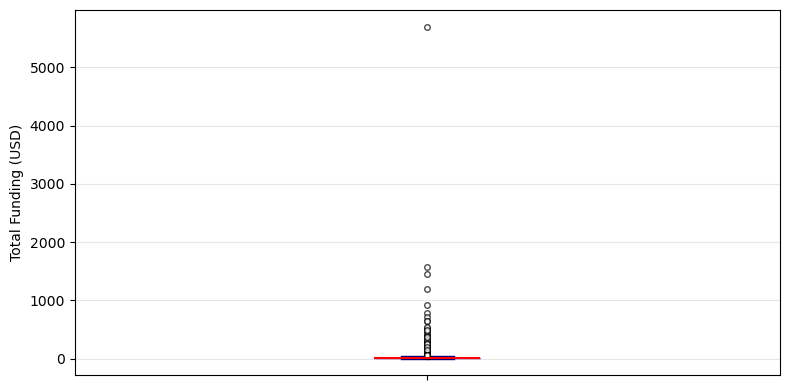

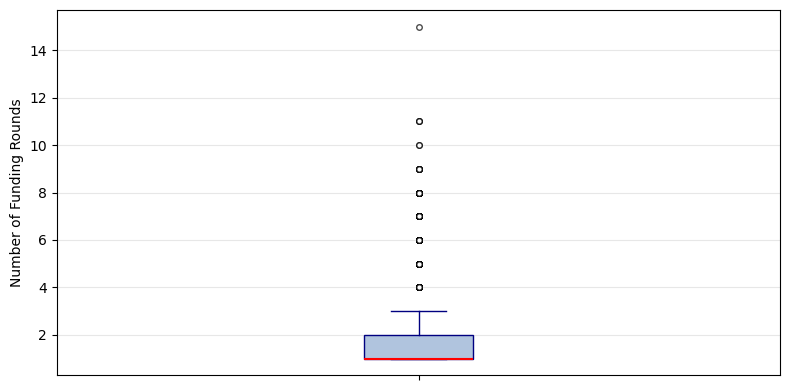

In [18]:
# Boxplots for the main funding variables.
# Funding total is shown in million USD for readability.

boxplot_data = []

if 'funding_total_usd' in df_eda.columns:
    funding_total_million = df_eda['funding_total_usd'].dropna() / 1_000_000
    if not funding_total_million.empty:
        boxplot_data.append({
            'data': funding_total_million,
            'title': 'Boxplot of Total Funding',
            'ylabel': 'Total Funding (USD)',
            'filename': 'boxplot_funding_total_usd_million.png'
        })

if 'funding_rounds' in df_eda.columns:
    funding_rounds = df_eda['funding_rounds'].dropna()
    if not funding_rounds.empty:
        boxplot_data.append({
            'data': funding_rounds,
            'title': 'Boxplot of Funding Rounds',
            'ylabel': 'Number of Funding Rounds',
            'filename': 'boxplot_funding_rounds.png'
        })

for item in boxplot_data:
    plt.figure(figsize=(8, 4))

    plt.boxplot(
        item['data'],
        vert=True,
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor='lightsteelblue', edgecolor='navy'),
        medianprops=dict(color='red', linewidth=1.5),
        whiskerprops=dict(color='navy'),
        capprops=dict(color='navy'),
        flierprops=dict(
            marker='o',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=4,
            alpha=0.7
        )
    )

    plt.ylabel(item['ylabel'], fontsize=10)
    plt.xticks([1], [''])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURE_DIR / item['filename'],
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

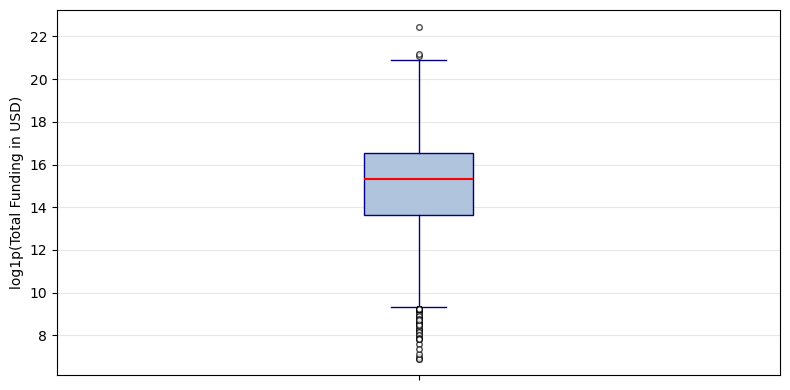

In [19]:
# Log-scale boxplot for total funding.
# This helps visualize the distribution when raw funding values are highly skewed.

if 'funding_total_usd' in df_eda.columns:
    s = df_eda['funding_total_usd'].dropna()

    if not s.empty and (s >= 0).all():
        log_funding_total = np.log1p(s)

        plt.figure(figsize=(8, 4))

        plt.boxplot(
            log_funding_total,
            vert=True,
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue', edgecolor='navy'),
            medianprops=dict(color='red', linewidth=1.5),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=4,
                alpha=0.7
            )
        )

        plt.ylabel('log1p(Total Funding in USD)', fontsize=10)
        plt.xticks([1], [''])
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()

        plt.savefig(
            EDA_FIGURE_DIR / 'boxplot_log1p_funding_total_usd.png',
            dpi=300,
            bbox_inches='tight'
        )

        plt.show()

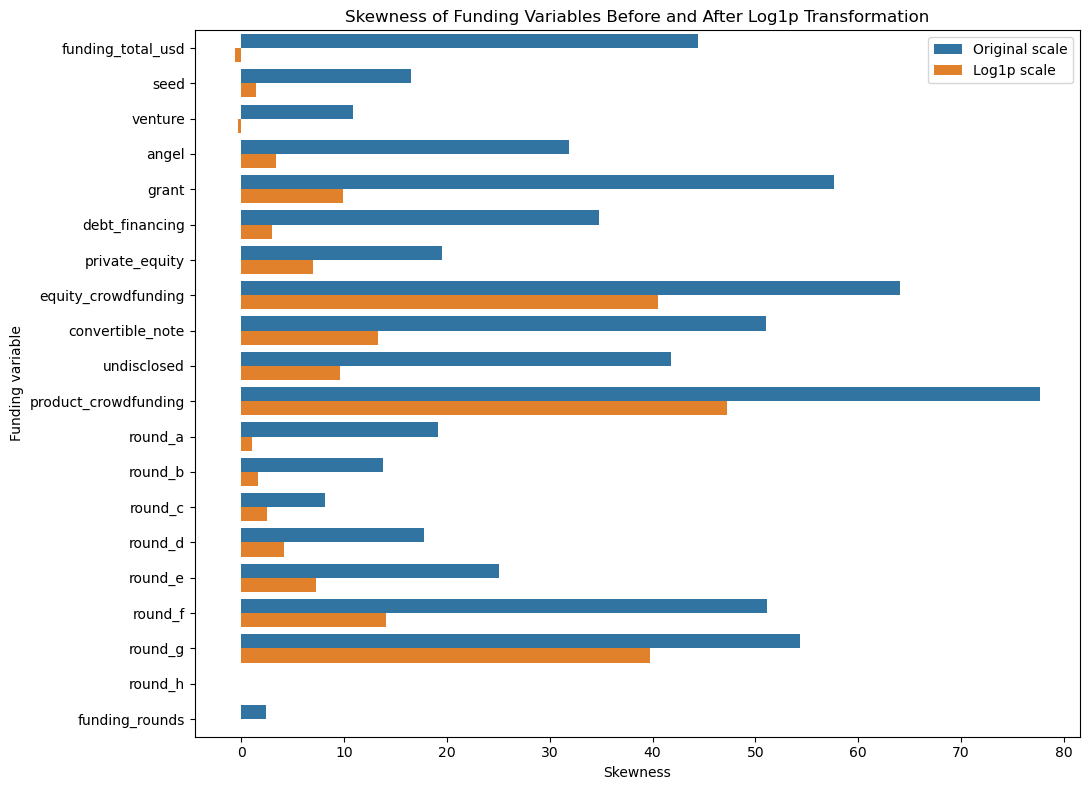

In [21]:
skewness_plot_data = funding_summary[
    ['variable', 'skewness', 'skewness_log1p']
].rename(columns={
    'skewness': 'skewness_original'
})

skewness_plot_long = skewness_plot_data.melt(
    id_vars='variable',
    value_vars=['skewness_original', 'skewness_log1p'],
    var_name='scale',
    value_name='skewness'
)

skewness_plot_long['scale'] = skewness_plot_long['scale'].replace({
    'skewness_original': 'Original scale',
    'skewness_log1p': 'Log1p scale'
})

plt.figure(figsize=(11, 8))

sns.barplot(
    data=skewness_plot_long,
    y='variable',
    x='skewness',
    hue='scale'
)

plt.title('Skewness of Funding Variables Before and After Log1p Transformation')
plt.xlabel('Skewness')
plt.ylabel('Funding variable')
plt.legend(title='')
plt.tight_layout()

plt.savefig(
    EDA_FIGURE_DIR / 'funding_skewness_before_after_log1p.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
# ============================================================
# 4.2.3 Funding Variable Distributions
# Variable-level distribution and skewness diagnostics
# ============================================================

funding_cols = [
    "funding_total_usd",
    "seed",
    "venture",
    "angel",
    "grant",
    "debt_financing",
    "private_equity",
    "equity_crowdfunding",
    "convertible_note",
    "undisclosed",
    "product_crowdfunding",
    "round_a",
    "round_b",
    "round_c",
    "round_d",
    "round_e",
    "round_f",
    "round_g",
    "round_h",
]

funding_cols = [col for col in funding_cols if col in df_eda.columns]

# Ensure numeric format
for col in funding_cols:
    df_eda[col] = pd.to_numeric(
        df_eda[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

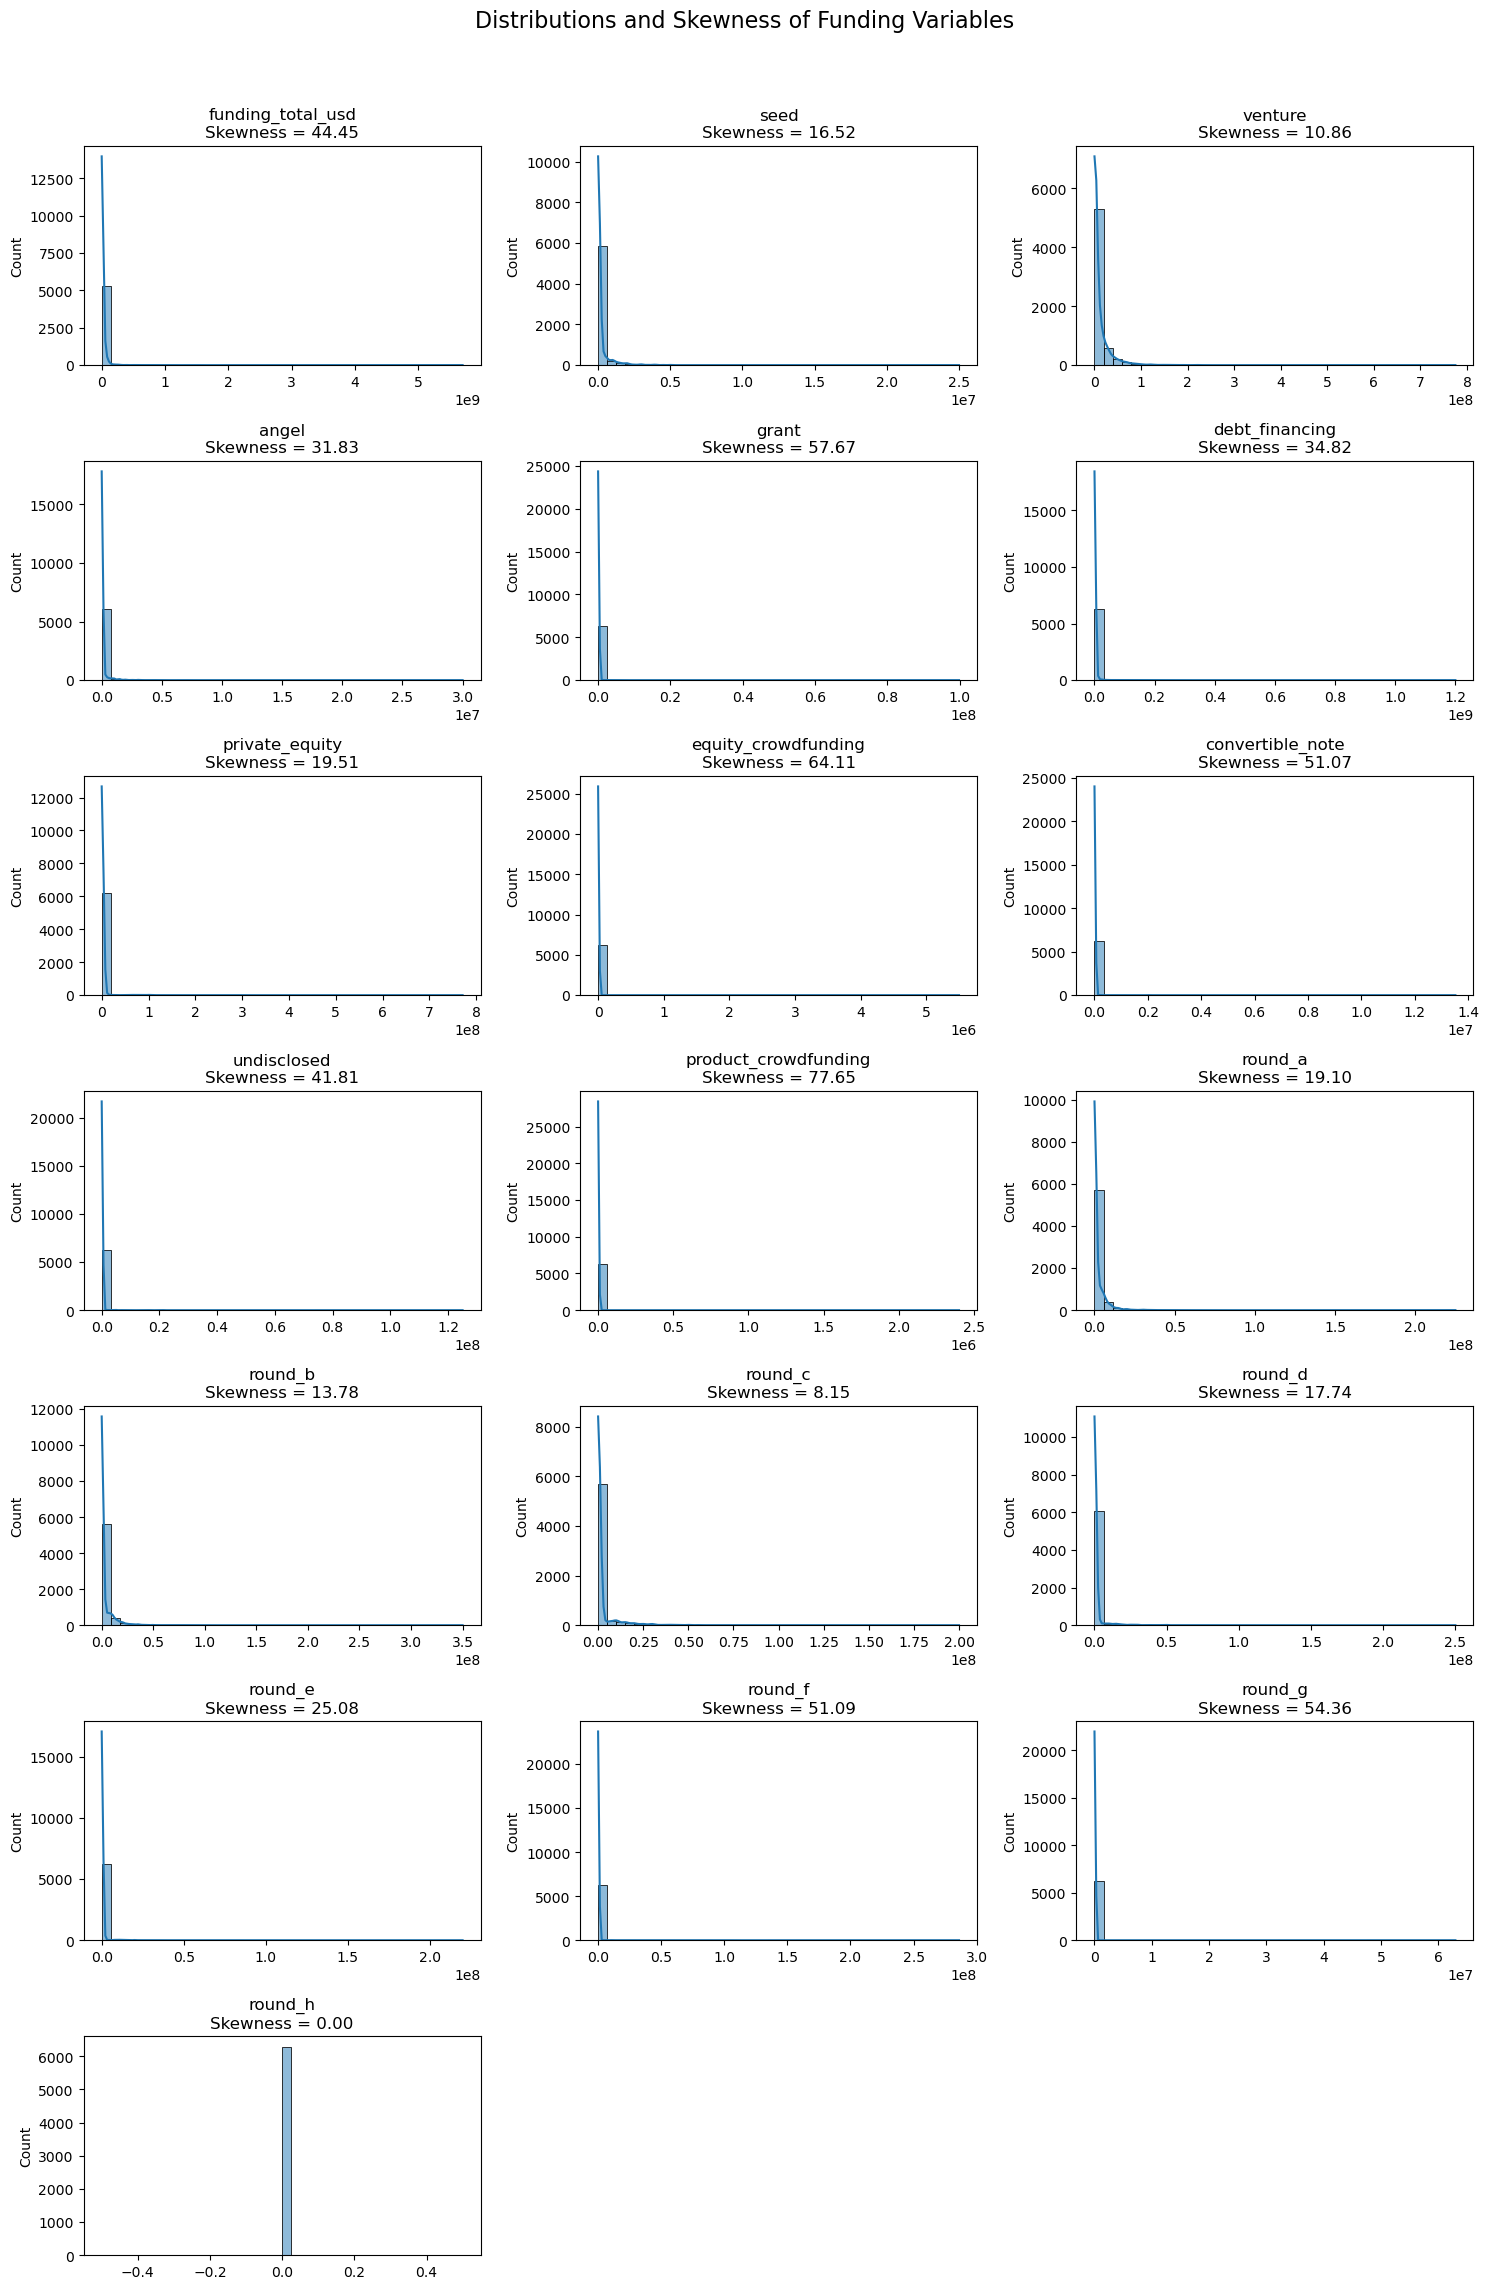

In [25]:
# Plot funding variable distributions with skewness values

n_cols = 3
n_rows = int(np.ceil(len(funding_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 3.2)
)

axes = axes.flatten()

for i, col in enumerate(funding_cols):
    s = df_eda[col].dropna()
    skew_value = s.skew()
    
    sns.histplot(
        s,
        bins=40,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col}\nSkewness = {skew_value:.2f}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distributions and Skewness of Funding Variables",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    EDA_FIGURE_DIR / "funding_variable_distributions_skewness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

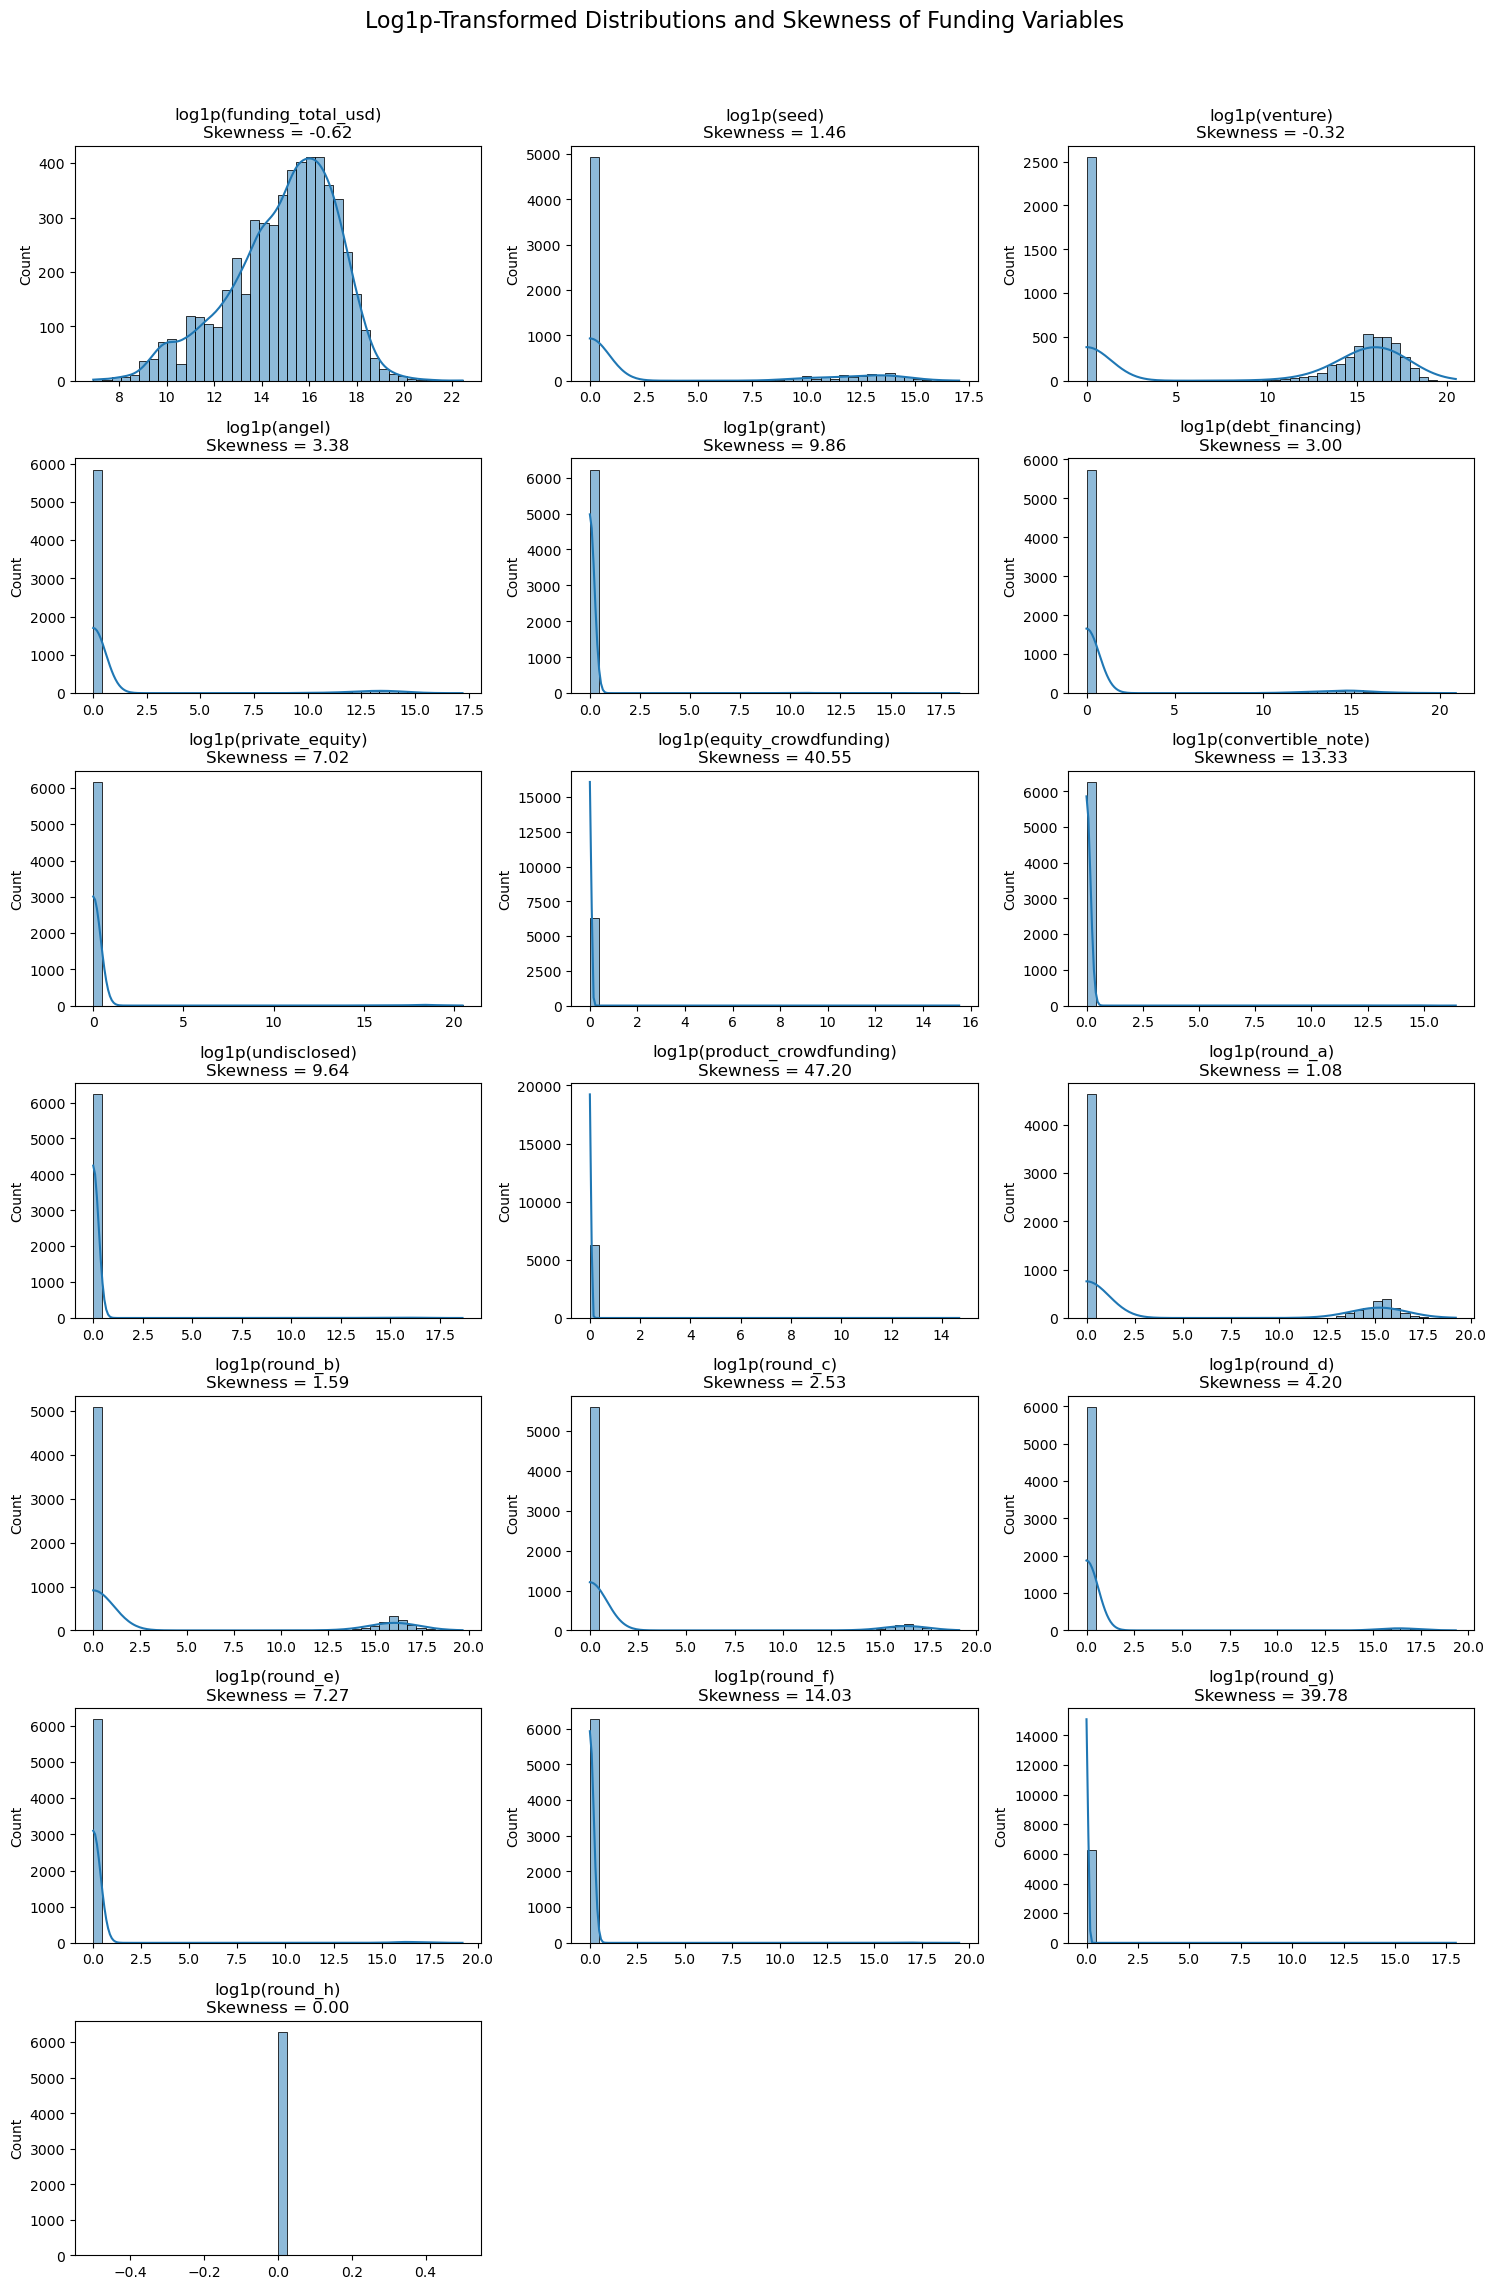

In [26]:
# Plot log1p-transformed funding variable distributions with skewness values

n_cols = 3
n_rows = int(np.ceil(len(funding_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 3.2)
)

axes = axes.flatten()

for i, col in enumerate(funding_cols):
    s = df_eda[col].dropna().clip(lower=0)
    s_log = np.log1p(s)
    skew_value = s_log.skew()
    
    sns.histplot(
        s_log,
        bins=40,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"log1p({col})\nSkewness = {skew_value:.2f}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Log1p-Transformed Distributions and Skewness of Funding Variables",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    EDA_FIGURE_DIR / "funding_variable_distributions_log1p_skewness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 4.2.4 Geographic and Market Distributions

This section describes the location and market composition of the binary sample. These diagnostics are useful for two reasons. First, categorical variables such as country and market often have long-tailed distributions. Second, the later subgroup analysis compares U.S. and non-U.S. firms, so the sample size of each group should be checked early.

Suggested thesis wording after running this notebook:

> Geographic and market variables were examined to assess sample concentration and long-tail category structure. This is relevant for both feature preprocessing and subgroup evaluation, because sparse categories can create unstable estimates and because the U.S./non-U.S. split is used later for error-pattern analysis.

In [202]:
cat_cols = [c for c in ['country_code', 'market'] if c in df_eda.columns]

for col in cat_cols:
    dist = (
        df_eda[col]
        .fillna('missing')
        .value_counts()
        .rename_axis(col)
        .reset_index(name='count')
    )
    dist['percentage'] = round(dist['count'] / len(df_eda) * 100,2)
    dist.to_csv(EDA_TABLE_DIR / f'{col}_distribution.csv', index=False)
    print(f'Top categories for {col}')
    display(dist.head(20))

Top categories for country_code


,country_code,count,percentage
0,USA,4248,67.4800
1,missing,628,9.9800
2,GBR,297,4.7200
3,CAN,169,2.6800
4,DEU,118,1.8700
5,ISR,107,1.7000
6,FRA,94,1.4900
7,CHN,61,0.9700
8,ESP,58,0.9200
9,IND,50,0.7900


Top categories for market


,market,count,percentage
0,Software,718,11.4100
1,Curated Web,459,7.2900
2,Mobile,342,5.4300
3,Biotechnology,322,5.1200
4,Enterprise Software,249,3.9600
5,missing,231,3.6700
6,Games,227,3.6100
7,Advertising,214,3.4000
8,E-Commerce,188,2.9900
9,Social Media,162,2.5700


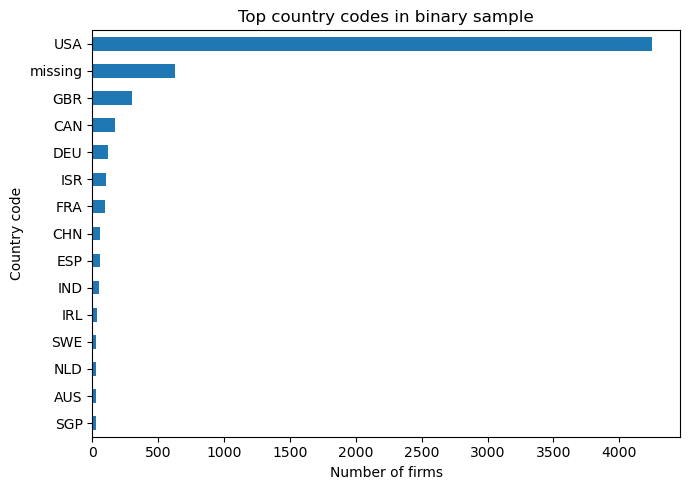

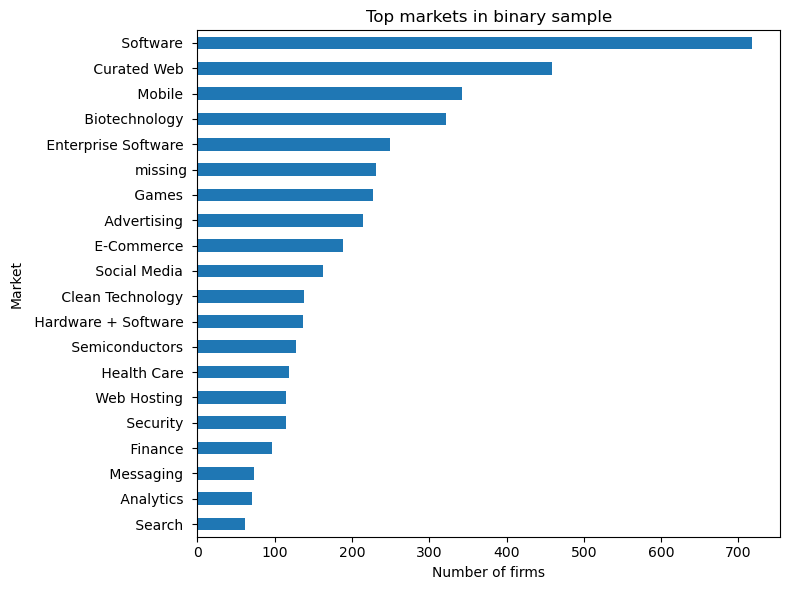

In [203]:
# Country distribution plot.
if 'country_code' in df_eda.columns:
    top_country = (
        df_eda['country_code']
        .fillna('missing')
        .value_counts()
        .head(15)
        .sort_values()
    )
    ax = top_country.plot(kind='barh', figsize=(7, 5))
    ax.set_title('Top country codes in binary sample')
    ax.set_xlabel('Number of firms')
    ax.set_ylabel('Country code')
    plt.tight_layout()
    plt.savefig(EDA_FIGURE_DIR / 'top_country_codes.png', dpi=300)
    plt.show()

# Market distribution plot.
if 'market' in df_eda.columns:
    top_market = (
        df_eda['market']
        .fillna('missing')
        .value_counts()
        .head(20)
        .sort_values()
    )
    ax = top_market.plot(kind='barh', figsize=(8, 6))
    ax.set_title('Top markets in binary sample')
    ax.set_xlabel('Number of firms')
    ax.set_ylabel('Market')
    plt.tight_layout()
    plt.savefig(EDA_FIGURE_DIR / 'top_markets.png', dpi=300)
    plt.show()

In [204]:
# U.S. vs non-U.S. subgroup size check for later Sub RQ3.
if 'country_code' in df_eda.columns:
    df_eda['is_usa'] = (df_eda['country_code'] == 'USA').astype(int)
    usa_table = (
        df_eda.assign(region_group=np.where(df_eda['is_usa'].eq(1), 'USA', 'Non-USA'))
        .groupby(['region_group', 'status'])
        .size()
        .reset_index(name='count')
    )
    usa_table['percentage_within_status'] = usa_table.groupby('status')['count'].transform(lambda x: x / x.sum() * 100)
    usa_table.to_csv(EDA_TABLE_DIR / 'usa_non_usa_by_status.csv', index=False)
    display(usa_table)

,region_group,status,count,percentage_within_status
0,Non-USA,acquired,907,24.5666
1,Non-USA,closed,1140,43.7956
2,USA,acquired,2785,75.4334
3,USA,closed,1463,56.2044


# 4.2.5 Data Quality and Leakage-Risk Diagnostics

This section flags duplicates, suspicious identifiers, post-outcome variables, and variables that may encode information too close to or after the eventual outcome. The goal is not to remove every flagged variable automatically in EDA, but to document why certain variables should be excluded or treated carefully during preprocessing and modeling.

Suggested thesis wording after running this notebook:

> Data quality and leakage-risk diagnostics were conducted before modeling. Exact duplicate rows were counted, identifier columns were inspected because they do not represent generalizable predictive information, and post-IPO or post-outcome variables were flagged as potential leakage-risk variables. These checks informed the later preprocessing decisions and feature exclusions.

In [205]:
# Exact duplicate rows.
duplicate_count = int(df_eda.duplicated().sum())
duplicate_share = duplicate_count / len(df_eda)

duplicate_table = pd.DataFrame({
    'diagnostic': ['exact_duplicate_rows'],
    'count': [duplicate_count],
    'share_of_binary_sample': [duplicate_share]
})
duplicate_table.to_csv(EDA_TABLE_DIR / 'duplicate_rows_check.csv', index=False)
display(duplicate_table)

,diagnostic,count,share_of_binary_sample
0,exact_duplicate_rows,0,0.0000


In [206]:
# Missingness and non-zero diagnostics for leakage-risk funding columns.
if post_outcome_or_leakage_risk_cols:
    leakage_numeric_summary = df_eda[post_outcome_or_leakage_risk_cols].copy()
    for col in post_outcome_or_leakage_risk_cols:
        leakage_numeric_summary[col] = pd.to_numeric(
            leakage_numeric_summary[col].astype(str).str.replace(',', '', regex=False),
            errors='coerce'
        )

    leakage_diag = pd.DataFrame({
        'column': post_outcome_or_leakage_risk_cols,
        'missing_ratio': leakage_numeric_summary.isna().mean().values,
        'zero_ratio_after_missing_as_zero': (leakage_numeric_summary.fillna(0) == 0).mean().values,
        'nonzero_count': (leakage_numeric_summary.fillna(0) != 0).sum().values,
    })
    leakage_diag.to_csv(EDA_TABLE_DIR / 'post_outcome_variable_diagnostics.csv', index=False)
    display(leakage_diag)
else:
    print('No configured post-outcome/leakage-risk funding columns found in this dataset.')

,column,missing_ratio,zero_ratio_after_missing_as_zero,nonzero_count
0,post_ipo_equity,0.0000,0.9986,9
1,post_ipo_debt,0.0000,0.9997,2
2,secondary_market,0.0000,0.9995,3


## 5. EDA summary checklist for thesis writing

After running the notebook, use the saved tables/figures to complete the following decisions:

1. **Status distribution**: report the raw status composition first, then explain why only `acquired` and `closed` are retained.
2. **Missing data**: identify variables with high missingness and justify imputation, exclusion, or missingness indicators.
3. **Temporal checks**: report the temporal coverage and justify removal of inconsistent date rows and very early first-funding observations.
4. **Funding distributions**: report skewness/zero inflation and justify log transformation or robust handling of funding variables.
5. **Geography/market**: report country/market concentration and justify rare-category grouping and U.S./non-U.S. subgroup analysis.
6. **Leakage diagnostics**: explicitly flag identifier columns, target-source columns, and post-IPO/post-outcome variables that should not be used as ordinary predictive features.

The notebook saves outputs under:

- `outputs/tables/eda/`
- `outputs/figures/eda/`

In [207]:
list(EDA_FIGURE_DIR.glob('*.png'))

[PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/boxplot_funding_rounds.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/remaining_sample_percentage_by_first_funding_cutoff.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/boxplot_log1p_funding_total_usd.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/top_country_codes.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/top_markets.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/boxplot_funding_total_usd_million.png'),
 PosixPath('/Users/bettykim/Desktop/Thesis/Code/outputs/figures/eda/raw_status_distribution.png')]